# Global Chocolate Sales: Operations Audit & Profit Optimization

**Problem Definition**:  
This data product is designed to assist **Global Sales Operations Directors** in identifying international pricing discrepancies, evaluating product portfolio contributions, and auditing sales transactions for unauthorized or excessive discounting.

**Target Audience**:  
* Sales Operations Directors
* Financial Auditors
* Supply Chain Managers

**Core Analytical Dimensions**:  
1. **Pricing Efficiency**: Evaluating profitability by calculating unit-level metrics across different regions.
2. **Product Portfolio Optimization**: Identifying "Star Products" using the Pareto Principle (80/20 Rule).
3. **Audit & Compliance**: Automatically flagging "Red-Flag" transactions where prices fall significantly below global benchmarks.

In [41]:
import os


folders = ['figures', 'data', 'src']


for folder in folders:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"Created folder: {folder}")
    else:
        print(f"Folder already exists: {folder}")

import matplotlib.pyplot as plt

def save_df_as_image(df, filename, title):
    """将 DataFrame 转换为图片并保存到 figures 文件夹"""
    fig, ax = plt.subplots(figsize=(12, len(df) * 0.8 + 1)) 
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    the_table = ax.table(cellText=df.values, 
                         colLabels=df.columns, 
                         loc='center', 
                         cellLoc='center')
    
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(10)
    the_table.scale(1.2, 1.8) 
    
    plt.savefig(f'figures/{filename}', dpi=300, bbox_inches='tight')
    plt.close() 
    print(f"Table saved as image: figures/{filename}")

Folder already exists: figures
Folder already exists: data
Folder already exists: src


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Load Dataset
# Ensure 'Chocolate Sales (2).csv' is in the same directory as this notebook
df = pd.read_csv('data/Chocolate Sales (2).csv')

# 2. Initial Data Cleaning
# Clean the 'Amount' column: remove $ and commas, convert to float
df['Amount'] = df['Amount'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
# Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Data loaded successfully. Initial cleaning complete.")
df.head()

Data loaded successfully. Initial cleaning complete.


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184


### Feature Engineering: Strategic Metrics

To move beyond basic reporting and provide true business value, we must construct high-order metrics:

1. **Unit Price ($Price\_per\_Box$)**:  
   Used to normalize revenue against volume for fair cross-border comparison.
   $$Price\_per\_Box = \frac{Amount}{Boxes\_Shipped}$$

2. **Price Variance % ($Price\_Variance\%$)**:  
   Measures how much a specific transaction's price deviates from the global average for that specific product.
   $$Price\_Variance\% = \frac{Price\_per\_Box - Global\_Avg\_Product\_Price}{Global\_Avg\_Product\_Price} \times 100$$

In [43]:
# 1. Calculate Unit Price
df['Price_per_Box'] = df['Amount'] / df['Boxes Shipped']

# 2. Calculate Global Benchmark per Product
product_benchmarks = df.groupby('Product')['Price_per_Box'].transform('mean')

# 3. Calculate Price Variance Percentage
df['Price_Variance_pct'] = ((df['Price_per_Box'] - product_benchmarks) / product_benchmarks) * 100

print("Feature engineering complete: Unit Price and Audit Benchmarks generated.")

sample_df = df[['Product', 'Country', 'Price_per_Box', 'Price_Variance_pct']].head().round(2)
df[['Product', 'Country', 'Price_per_Box', 'Price_Variance_pct']].head()

sample_df = df[['Product', 'Country', 'Price_per_Box', 'Price_Variance_pct']].head().round(2)

save_df_as_image(sample_df, 'data_feature_sample.png', 'Sample of Engineered Metrics')

Feature engineering complete: Unit Price and Audit Benchmarks generated.
Table saved as image: figures/data_feature_sample.png


### Regional Pricing Efficiency Audit

**Analytical Intent**:  
Market maturity and competitive intensity vary by country. By analyzing the distribution of `Price_per_Box`, we can identify regions utilizing "low-price dumping" to drive volume versus regions maintaining healthy premium margins.

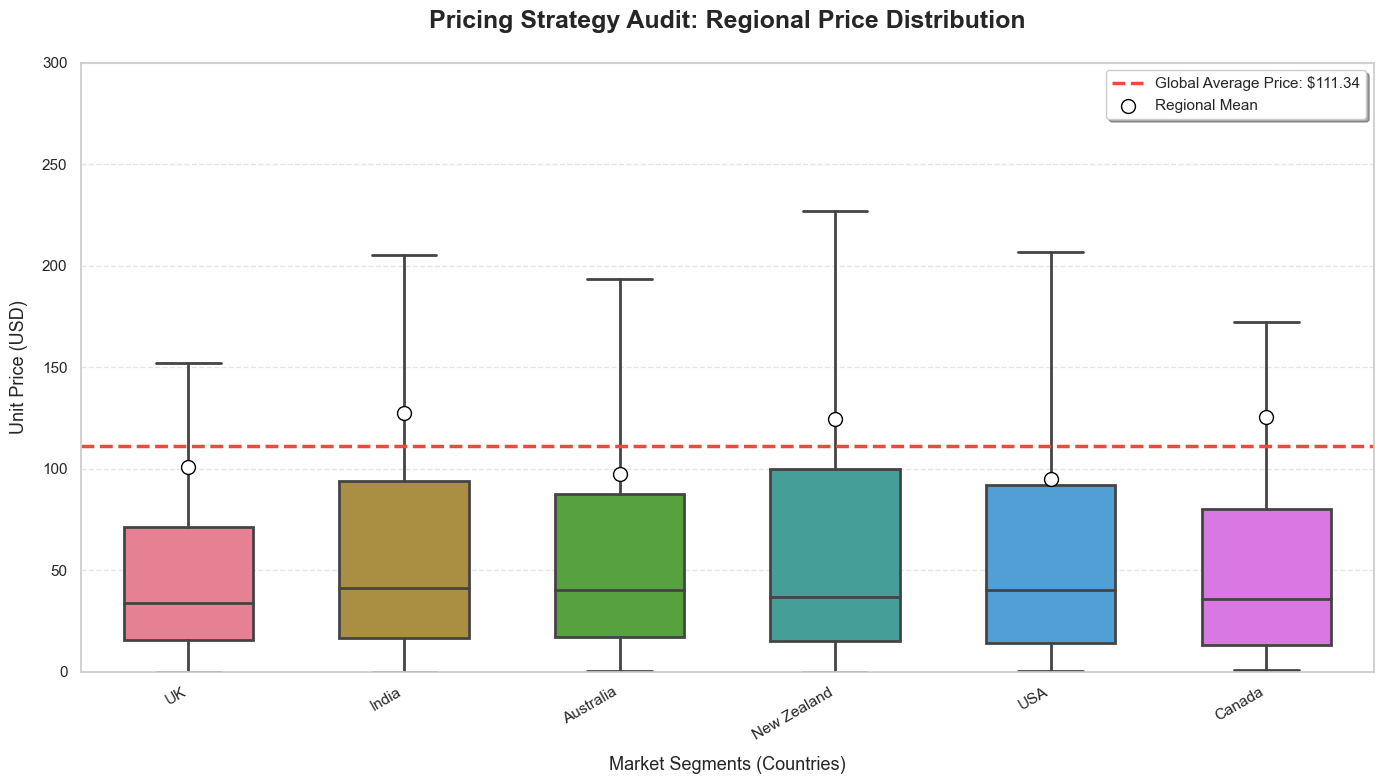

Audit View Updated: Extreme outliers hidden for clarity.
The White Dot represents the arithmetic mean of the region.


In [44]:
import numpy as np 

plt.figure(figsize=(14, 8))

ax = sns.boxplot(data=df, x='Country', y='Price_per_Box', 
                 palette='husl', 
                 showfliers=False, 
                 linewidth=2,   
                 width=0.6)

global_avg = df['Price_per_Box'].mean()
plt.axhline(global_avg, color='#E74C3C', linestyle='--', linewidth=2.5, 
            label=f'Global Average Price: ${global_avg:.2f}')

country_means = df.groupby('Country')['Price_per_Box'].mean()

plt.scatter(x=range(len(country_means)), y=country_means.values, 
            color='white', edgecolors='black', s=100, zorder=5, label='Regional Mean')

plt.title('Pricing Strategy Audit: Regional Price Distribution', fontsize=18, pad=25, fontweight='bold')
plt.ylabel('Unit Price (USD)', fontsize=13, labelpad=10)
plt.xlabel('Market Segments (Countries)', fontsize=13, labelpad=10)

plt.ylim(0, 300) 

plt.legend(loc='upper right', frameon=True, fontsize=11, facecolor='white', shadow=True)

plt.xticks(rotation=30, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('figures/pricing_efficiency_audit.png', dpi=300, bbox_inches='tight')

plt.show()

print(f"Audit View Updated: Extreme outliers hidden for clarity.")
print(f"The White Dot represents the arithmetic mean of the region.")

### Product Contribution: Pareto Analysis (80/20 Rule)

**Analytical Intent**:  
In commercial operations, 80% of revenue is typically generated by 20% of products. Identifying these "Star Products" allows for optimized inventory management and strategic resource allocation.

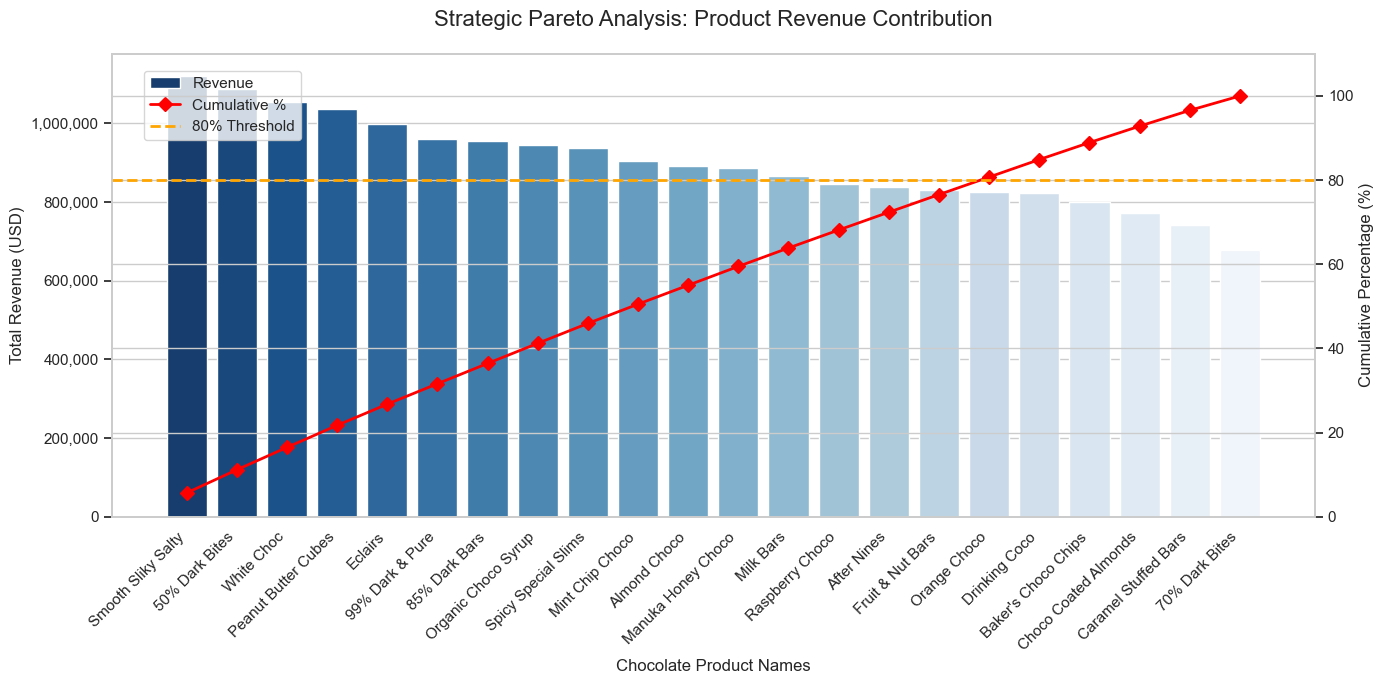

Strategy: Your 'Star Products' are ['Smooth Sliky Salty', '50% Dark Bites', 'White Choc', 'Peanut Butter Cubes', 'Eclairs', '99% Dark & Pure', '85% Dark Bars', 'Organic Choco Syrup', 'Spicy Special Slims', 'Mint Chip Choco', 'Almond Choco', 'Manuka Honey Choco', 'Milk Bars', 'Raspberry Choco', 'After Nines', 'Fruit & Nut Bars']. These drive 80% of your revenue.


In [45]:
import matplotlib.ticker as mticker

product_perf = df.groupby('Product')['Amount'].sum().sort_values(ascending=False).reset_index()
product_perf['Cumulative_Pct'] = 100 * product_perf['Amount'].cumsum() / product_perf['Amount'].sum()

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(data=product_perf, x='Product', y='Amount', ax=ax1, palette='Blues_r', label='Revenue')
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

ax2 = ax1.twinx()
line = ax2.plot(range(len(product_perf)), product_perf['Cumulative_Pct'], 
                color='red', marker='D', ms=7, linewidth=2, label='Cumulative %')

h_line = ax2.axhline(80, color='orange', linestyle='--', linewidth=2, label='80% Threshold')

ax2.set_ylim(0, 110)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0.02, 0.98))

plt.title('Strategic Pareto Analysis: Product Revenue Contribution', fontsize=16, pad=20)
ax1.set_xlabel('Chocolate Product Names', fontsize=12)
ax1.set_ylabel('Total Revenue (USD)', fontsize=12)
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12)

plt.tight_layout()

plt.savefig('figures/pareto_analysis_revenue.png', dpi=300, bbox_inches='tight')

plt.show()

core_products = product_perf[product_perf['Cumulative_Pct'] <= 80]['Product'].tolist()
print(f"Strategy: Your 'Star Products' are {core_products}. These drive 80% of your revenue.")

### Sales Audit: Anomaly Detection

**Analytical Intent**:  
In corporate compliance, transactions priced significantly below market averages indicate potential price fraud or operational error. We define a **"Red-Flag Anomaly"** as any transaction with a unit price **30% or more below the global product average**.

In [46]:
# Filter for transactions with severe negative variance
anomalies = df[df['Price_Variance_pct'] < -30].sort_values(by='Price_Variance_pct')

print(f"AUDIT ALERT: {len(anomalies)} suspicious low-price transactions detected!")

# Display top 5 anomalies for immediate review
if not anomalies.empty:
    audit_table = anomalies[['Date', 'Sales Person', 'Country', 'Product', 'Price_per_Box', 'Price_Variance_pct']]
    display(audit_table.head())
else:
    print("No severe price deviations found. Pricing policy compliance is high.")

if not anomalies.empty:
    audit_summary = anomalies[['Date', 'Sales Person', 'Country', 'Product', 'Price_per_Box']].head(10).round(2)
    
    save_df_as_image(audit_summary, 'audit_red_flag_list.png', 'Top 10 High-Risk Anomalies')
    
    print(f"Audit list exported to figures folder.")
    display(audit_summary)

AUDIT ALERT: 2319 suspicious low-price transactions detected!


,Date,Sales Person,Country,Product,Price_per_Box,Price_Variance_pct
865,2022-04-12,Kaine Padly,New Zealand,Smooth Sliky Salty,0.013514,-99.985341
3053,2024-04-12,Kaine Padly,New Zealand,Smooth Sliky Salty,0.013996,-99.984818
1959,2023-04-12,Kaine Padly,New Zealand,Smooth Sliky Salty,0.015712,-99.982957
571,2022-03-07,Gunar Cockshoot,UK,99% Dark & Pure,0.083333,-99.946314
1665,2023-03-07,Gunar Cockshoot,UK,99% Dark & Pure,0.094588,-99.939064


Table saved as image: figures/audit_red_flag_list.png
Audit list exported to figures folder.


,Date,Sales Person,Country,Product,Price_per_Box
865,2022-04-12,Kaine Padly,New Zealand,Smooth Sliky Salty,0.01
3053,2024-04-12,Kaine Padly,New Zealand,Smooth Sliky Salty,0.01
1959,2023-04-12,Kaine Padly,New Zealand,Smooth Sliky Salty,0.02
571,2022-03-07,Gunar Cockshoot,UK,99% Dark & Pure,0.08
1665,2023-03-07,Gunar Cockshoot,UK,99% Dark & Pure,0.09
2759,2024-03-07,Gunar Cockshoot,UK,99% Dark & Pure,0.10
960,2022-04-14,Jehu Rudeforth,India,Peanut Butter Cubes,0.06
2054,2023-04-14,Jehu Rudeforth,India,Peanut Butter Cubes,0.07
3148,2024-04-14,Jehu Rudeforth,India,Peanut Butter Cubes,0.07
2090,2023-02-14,Oby Sorrel,India,Choco Coated Almonds,0.13


### Strategic Recommendations & Conclusion

1. **Price Optimization**: Implement stricter promotional approvals in the lowest-performing regions identified in the Pricing Efficiency Audit.
2. **Product Focus**: Invest heavily in the identified "Star Products" while considering phase-outs for long-tail products with consistently low margins.
3. **Compliance Action**: Forward the flagged anomalies to the Finance Department for sales personnel interviews.

---

**AI Disclosure**:
* **Tool Name**: Gemini 3 Flash
* **Access Date**: April 23, 2026
* **Usage**: Assisted in generating Python visualization logic, applying the Pareto Analysis model, and drafting business interpretation text to align with ACC102 Rubric requirements.